# Long Short-Term Memory (LSTM) - PyTorch

In [3]:
import os
import random
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# -----------------------------
# Reproducibility: Set seeds
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# -----------------------------
# Device setup
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -----------------------------
# Generate synthetic dataset
# -----------------------------
samples, seq_len, features = 1400, 30, 3
X = np.random.normal(size=(samples, seq_len, features)).astype("float32")

signal = (
    X[:, -10:, 0].mean(axis=1) +
    0.5 * X[:, :10, 1].mean(axis=1)
)
y = (signal > 0.05).astype("int64")

# Train/test split
train_loader = DataLoader(
    TensorDataset(torch.tensor(X[:1000]), torch.tensor(y[:1000])),
    batch_size=64,
    shuffle=True,
)
test_x = torch.tensor(X[1000:], device=device)
test_y = torch.tensor(y[1000:], device=device)

# -----------------------------
# Define LSTM model
# -----------------------------
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim: int = 3, hidden_dim: int = 32):
        super().__init__()
        self.recurrent = nn.LSTM(
            input_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=False,
        )
        self.classifier = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        output, _ = self.recurrent(x)
        return self.classifier(output[:, -1, :])

# -----------------------------
# Training setup
# -----------------------------
model = LSTMClassifier().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# -----------------------------
# Training loop
# -----------------------------
for epoch in range(10):
    model.train()
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(batch_x), batch_y)
        loss.backward()
        optimizer.step()

    # Evaluation
    model.eval()
    with torch.no_grad():
        accuracy = (model(test_x).argmax(dim=1) == test_y).float().mean().item()
    print(f"epoch={epoch+1:02d} accuracy={accuracy:.3f}")

Using device: cpu
epoch=01 accuracy=0.688
epoch=02 accuracy=0.543
epoch=03 accuracy=0.627
epoch=04 accuracy=0.785
epoch=05 accuracy=0.790
epoch=06 accuracy=0.795
epoch=07 accuracy=0.822
epoch=08 accuracy=0.835
epoch=09 accuracy=0.835
epoch=10 accuracy=0.825


Epoch [5/30], Loss: 0.449351
Epoch [10/30], Loss: 0.373448
Epoch [15/30], Loss: 0.249706
Epoch [20/30], Loss: 0.198392
Epoch [25/30], Loss: 0.122263
Epoch [30/30], Loss: 0.078453


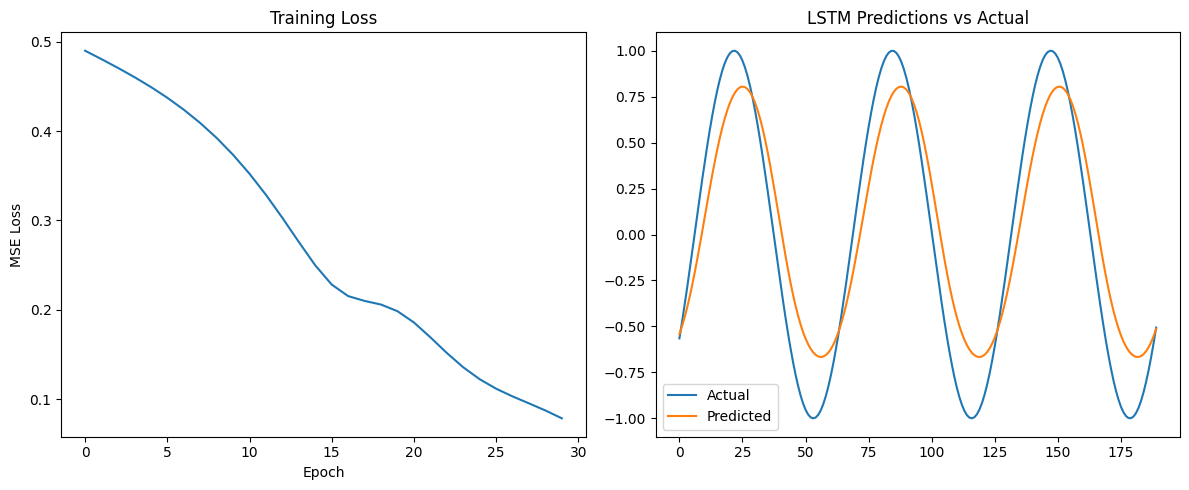

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# -----------------------------
# 1. Generate Sine Wave Dataset
# -----------------------------
def create_sine_data(seq_length=50, num_samples=1000):
    x = np.linspace(0, 100, num_samples)
    y = np.sin(x)

    sequences = []
    targets = []

    for i in range(len(y) - seq_length):
        sequences.append(y[i:i+seq_length])
        targets.append(y[i+seq_length])

    return np.array(sequences), np.array(targets)

SEQ_LEN = 50
X, y = create_sine_data(SEQ_LEN)

# Convert to tensors
X = torch.FloatTensor(X).unsqueeze(-1)  # (samples, seq_len, 1)
y = torch.FloatTensor(y).unsqueeze(-1)  # (samples, 1)

# Train/Test split
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# -----------------------------
# 2. LSTM Model
# -----------------------------
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)             # (batch, seq_len, hidden)
        out = out[:, -1, :]              # Last time step
        out = self.fc(out)
        return out

model = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# -----------------------------
# 3. Training Loop
# -----------------------------
EPOCHS = 30
losses = []

for epoch in range(EPOCHS):
    model.train()

    output = model(X_train)
    loss = criterion(output, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {loss.item():.6f}")

# -----------------------------
# 4. Evaluate on Test Data
# -----------------------------
model.eval()
with torch.no_grad():
    predictions = model(X_test).squeeze().numpy()
    actual = y_test.squeeze().numpy()

# -----------------------------
# 5. Visualization
# -----------------------------

# Loss Curve
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

# Predictions vs Actual
plt.subplot(1,2,2)
plt.plot(actual, label="Actual")
plt.plot(predictions, label="Predicted")
plt.title("LSTM Predictions vs Actual")
plt.legend()

plt.tight_layout()
plt.show()